# NLP Basics. Análisis del libro "El Quijote"

In [ ]:
#  Si no tenemos el módulo podemos descargarlo mediante:
#! pip install nltk
#! pip install wordcloud

## Importación de librerías
Se trata de las bibliotecas necesarias para el procesamiento del lenguaje natural. NLTK (Natural Language Toolkit) es una de las bibliotecas principales mencionadas en el PDF para tareas de PLN. Se importan módulos específicos para tokenización, eliminación de stopwords, stemming y análisis de frecuencia de palabras. Matplotlib se utiliza para visualización.

In [ ]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.metrics.distance import edit_distance
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('cess_esp')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package cess_esp to /root/nltk_data...
[nltk_data]   Unzipping corpora/cess_esp.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

## Carga del texto
Esta celda carga el texto de "El Quijote" desde el archivo proporcionado. Es un paso crucial en la extracción de datos, como se menciona en la sección de "Extracción de datos" del documento explicativo del tema.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
with open("/content/drive/MyDrive/el_quijote.txt", 'r', encoding='utf-8') as myfile:
    # Obtenemos el quijote como un solo string: quijote
    quijote = myfile.read().replace('\n', ' ')

## Tokenización
Es una de las técnicas de preprocesamiento mencionadas en el tema. Esta técnica divide el texto en unidades más pequeñas (tokens), generalmente palabras.

In [ ]:
tokens = word_tokenize(quijote, language="spanish")

# Los diez primeros tokens, i.e. pseudo-palabras
tokens[:10]

['El',
 'ingenioso',
 'hidalgo',
 'don',
 'Quijote',
 'de',
 'la',
 'Mancha',
 'TASA',
 'Yo']

In [ ]:
len(tokens)

438949

In [ ]:
# Vemos las diez palabras más frecuentes
freq_w_quijote = FreqDist(tokens)
freq_w_quijote.most_common(10)

[(',', 40174),
 ('que', 20520),
 ('de', 17988),
 ('y', 17155),
 ('la', 10201),
 ('a', 9525),
 ('.', 7970),
 ('el', 7960),
 ('en', 7900),
 ('no', 5760)]

## Eliminación de stopwords
Las *stopwords* son palabras de la lengua que apenas tienen valor semántico (de significado), que por lo tanto para poder sacar conclusiones del texto omitiremos.

In [ ]:
stop_words = set(stopwords.words('spanish'))

In [ ]:
# Las 10 primeras
stopwords.words('spanish')[:10]

['de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se']

Esta celda elimina las stopwords (palabras comunes que no aportan significado sustancial) y convierte todas las palabras a minúsculas. Este paso es parte del preprocesamiento de textos, como se describe en el tema.

In [ ]:
filtered_tokens = [word.lower() for word in tokens if word.isalnum() and word.lower() not in stop_words]

In [ ]:
len(set(filtered_tokens))

22447

In [ ]:
# Los diez primeros tokens una vez eliminadas las stopwords
filtered_tokens[:10]

['ingenioso',
 'hidalgo',
 'don',
 'quijote',
 'mancha',
 'tasa',
 'juan',
 'gallo',
 'andrada',
 'escribano']

In [ ]:
# Vemos las diez palabras más frecuentes nuevamente
freq_w_quijote = FreqDist(filtered_tokens)
freq_w_quijote.most_common(10)

[('don', 2644),
 ('si', 1900),
 ('quijote', 1653),
 ('sancho', 1627),
 ('tan', 1222),
 ('ser', 1056),
 ('bien', 995),
 ('señor', 982),
 ('así', 969),
 ('dijo', 930)]

## Stemming
Aquí se aplica el stemming, otra técnica de preprocesamiento explicada aen el tema. El stemming reduce las palabras a su forma raíz o "stem".


In [ ]:
stemmer = SnowballStemmer('spanish')
stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]

In [ ]:
stemmed_tokens[:10]

['ingeni',
 'hidalg',
 'don',
 'quijot',
 'manch',
 'tas',
 'juan',
 'gall',
 'andrad',
 'escriban']

In [ ]:
len(stemmed_tokens)

177099

## Análisis de frecuencia
Esta celda realiza un análisis de frecuencia de los tokens procesados, similar al concepto de frecuencia de términos mencionado en el tema.

In [ ]:
fdist = FreqDist(stemmed_tokens)

In [ ]:
# Mostramos los 10 tokens con mayores frecuencias absolutas
for word, frequency in fdist.most_common(10):
    print(f"{word}: {frequency}")

don: 2653
si: 1900
señor: 1717
quijot: 1658
sanch: 1636
tan: 1222
hac: 1158
buen: 1098
ser: 1057
bien: 1014


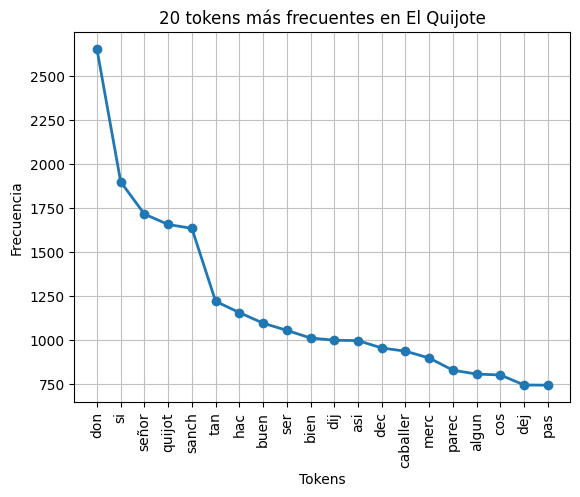

In [ ]:
# Veamos de manera gráfica el resultado:
fdist.plot(20, cumulative=False, marker='o')
plt.title('20 tokens más frecuentes en El Quijote')
plt.xlabel('Tokens')
plt.ylabel('Frecuencia')
plt.show()

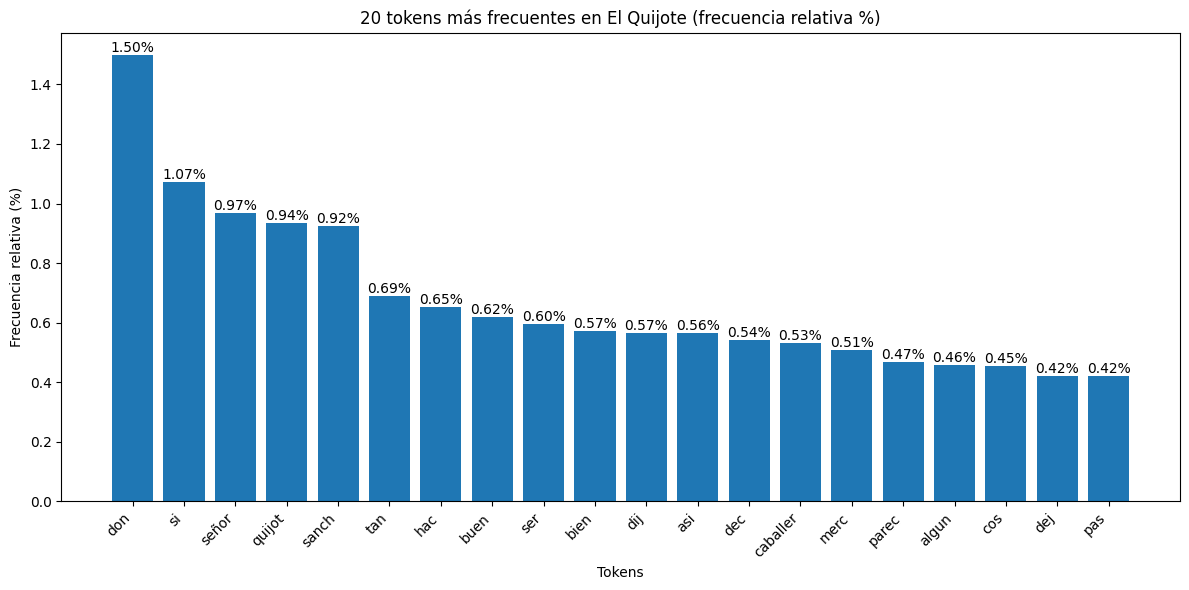

In [ ]:
def plot_freqdist_freq(fdist, max_num=30, title='Distribución de frecuencias'):
    total = sum(fdist.values())
    freqs = [(word, (freq/total)*100) for word, freq in fdist.most_common(max_num)]
    words, frequencies = zip(*freqs)

    plt.figure(figsize=(12, 6))
    plt.bar(words, frequencies)
    plt.title(title)
    plt.xlabel('Tokens')
    plt.ylabel('Frecuencia relativa (%)')
    plt.xticks(rotation=45, ha='right')
    # Añadir etiquetas de porcentaje en las barras
    for i, v in enumerate(frequencies):
        plt.text(i, v, f'{v:.2f}%', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

plot_freqdist_freq(fdist, max_num=20, title='20 tokens más frecuentes en El Quijote (frecuencia relativa %)')


## El Quijote en "lenguage máquina"
A partir de los tokens filtrados, vamos a producir una cadena de texto que contiene todas las palabras significativas de "El Quijote", en minúsculas, sin signos de puntuación ni palabras vacías, separadas por espacios.

Es importante notar que este proceso reduce significativamente el texto original, eliminando gran parte de su estructura gramatical y palabras de función, pero manteniendo las palabras con contenido semántico. Esto puede ser útil para ciertos tipos de análisis de texto, como la extracción de temas o el análisis de frecuencia de palabras, pero no preserva la legibilidad o el estilo literario del texto original.

In [ ]:
filtered_tokens_join = ' '.join(filtered_tokens)

In [ ]:
import spacy

In [ ]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 68.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = spacy.load("es_core_news_sm")

In [ ]:
tokens_join = ' '.join(filtered_tokens)

In [ ]:
len(tokens_join)
nlp.max_length = 1274000

In [ ]:
tokens_to_nlp = nlp(tokens_join)
lemmas = [i.lemma_.lower() for i in tokens_to_nlp if i.is_alpha]

print("LEMMAS:", lemmas)

LEMMAS: ['ingenioso', 'hidalgo', 'don', 'quijote', 'manchar', 'tasa', 'juan', 'gallo', 'andrado', 'escribano', 'cámarar', 'rey', 'señor', 'residir', 'consejo', 'certifico', 'dar', 'fe', 'visto', 'señor', 'dél', 'libro', 'intitulado', 'ingenioso', 'hidalgo', 'manchar', 'compuesto', 'miguel', 'cervantes', 'saavedra', 'tasar', 'cada', 'pliego', 'dicho', 'libro', 'tres', 'maravedís', 'medio', 'ochenta', 'tres', 'pliego', 'dicho', 'precio', 'montar', 'dicho', 'libro', 'dociento', 'noventa', 'maravedís', 'medio', 'vender', 'papel', 'dar', 'licencia', 'precio', 'poder', 'vender', 'mandar', 'tasa', 'poner', 'principio', 'dicho', 'libro', 'poder', 'vender', 'dello', 'constar', 'di', 'presente', 'valladolid', 'veinte', 'día', 'mes', 'deciembre', 'mil', 'seisciento', 'cuatro', 'año', 'juan', 'gallo', 'andrado', 'testimonio', 'erratas', 'libro', 'cosa', 'digno', 'correspondo', 'original', 'testimonio', 'haber', 'correcto', 'di', 'fee', 'colegio', 'madre', 'dios', 'teólogo', 'primero', 'diciembre',

In [ ]:
lemmas_size = len(lemmas)
lemmas_size

177092

In [ ]:
# El Quijote tratado en "lenguage máquina"
#filtered_tokens_join

## Visualización de los tokens como "nube de palabras"
Creamos una nube de palabras (word cloud) utilizando la biblioteca WordCloud en Python:
1. `WordCloud()`: Esta es la clase principal de la biblioteca WordCloud que se utiliza para generar la nube de palabras.
2. Parámetros:
   - `width = 1000`: Establece el ancho de la imagen resultante en 1000 píxeles.
   - `height = 500`: Establece la altura de la imagen resultante en 500 píxeles.
   - `relative_scaling = 0.5`: Este parámetro controla cómo se escalan los tamaños de las palabras en relación con sus frecuencias. Un valor de 0.5 significa que el tamaño de la palabra es proporcional a la raíz cuadrada de su frecuencia.
3. `.generate(filtered_tokens_join)`: Este método toma el texto procesado (`filtered_tokens_join`) y genera la nube de palabras a partir de él.

La variable `filtered_tokens_join` debe ser una cadena de texto que contiene todas las palabras filtradas y procesadas de "El Quijote", unidas por espacios. Esta cadena se obtiene después de aplicar técnicas de preprocesamiento como tokenización, eliminación de stopwords, y posiblemente stemming o lematización[1].

El resultado de esta operación es un objeto WordCloud que contiene la representación visual de las palabras más frecuentes en el texto procesado de "El Quijote".

Esta visualización permite identificar rápidamente los términos más relevantes o frecuentes en el texto, proporcionando una representación gráfica intuitiva del contenido de "El Quijote".

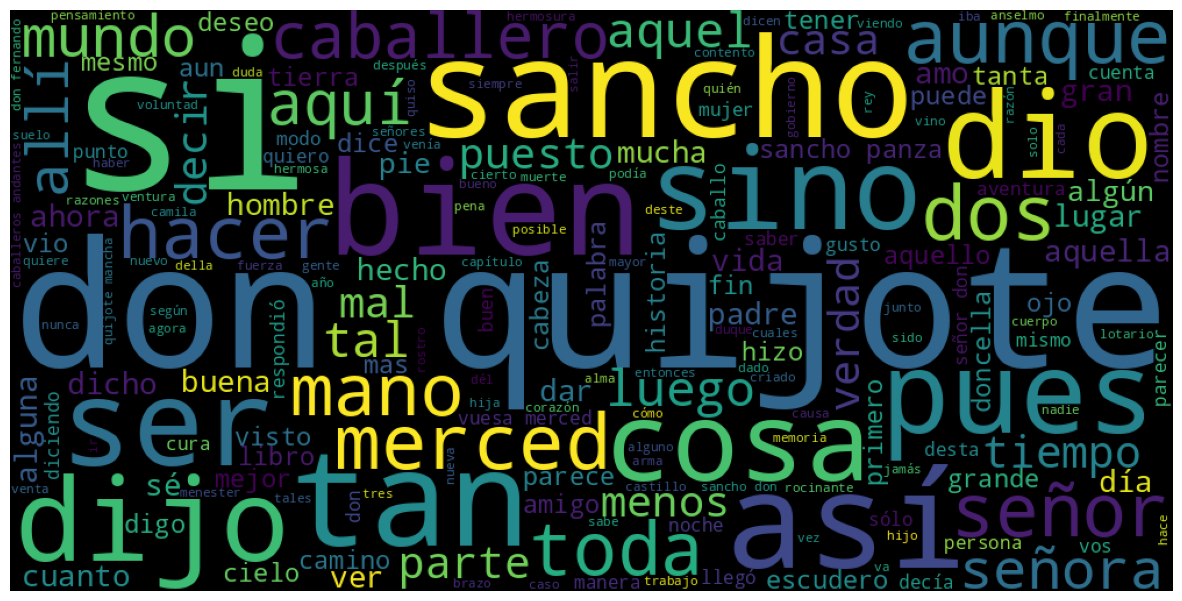

In [ ]:
wordcloud = WordCloud(width = 1000, height = 500, relative_scaling = 0.5).generate(filtered_tokens_join)
plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()